# Training an agent via GRPO on financial data

This notebook follows the application of the GRPO method to the sliding puzzle problem. The objective is to establish a stable and efficient environment to train a Deep Learning model using the GRPO technique. The goal is not to predict the future behavior of an ETF or a specific stock. Instead, we aim to determine if an agent can learn to make decisions that increase portfolio value by observing the current state of a user's holdings alongside the historical price variations of those assets over a specific lookback period.

This notebook outlines a two-phase training strategy. Initially, we provide the model with look-ahead access to future stock data to establish a baseline for optimal decision-making. In the second phase, this foresight is removed, and the agent is restricted to historical price variations of the ETFs or stocks. This transition allows us to evaluate the model's ability to generalize and make effective portfolio decisions using only past market indicators.

In [147]:
from typing import Callable, Tuple
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import torch.nn.functional as F
import copy
from collections import deque
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F
import heapq


In [148]:
# That doesn't concern you; I've added the plot.py and data.py files to the repository

from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/MyDrive/tradeRL')

from data import simulate_curves
from plot import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Reinforcement Learning Core: The GRPO Intelligence

I am a massive fan of reinforcement learning, and the functions presented here represent the absolute heart of the GRPO (Group Relative Policy Optimization) method. This approach is particularly elegant because it optimizes the policy by comparing the relative performance of a group of samples rather than relying on a complex, separate critic network. This significantly simplifies the global architecture while remaining extremely high-performing.

I won't dive into the deep technical specifics here to keep things efficient and direct. However, if you want to explore the mathematical logic and the deep reasoning behind DeepSeekMath, you can find detailed explanations at these links:

https://aipapersacademy.com/deepseekmath-grpo/

https://arxiv.org/abs/2402.03300.

In [149]:
def run_policy(num_samples: int,
               num_steps: int,
               env_context: dict,
               context_modifier: Callable[[dict], dict],
               initial_states: torch.Tensor,
               initial_inputs: torch.Tensor,
               policy_net: torch.nn.Module,
               transition_fn: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor],
               reward_fn: Callable[[dict, torch.Tensor, torch.Tensor], torch.Tensor]) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:

    current_states = initial_states.repeat_interleave(num_samples, dim=0).clone()
    current_inputs = initial_inputs.repeat_interleave(num_samples, dim=0).clone()
    current_context = context_modifier(env_context)

    current_predictions, current_logits = policy_net(current_inputs)
    current_dist = Categorical(logits=current_logits)
    current_actions = current_dist.sample()

    states_history = torch.zeros(num_steps, *current_states.shape)
    inputs_history = torch.zeros(num_steps, *current_inputs.shape)
    actions_history = torch.zeros(num_steps, *current_actions.shape)
    rewards_history = torch.zeros(num_steps, current_actions.shape[0])
    predictions_history = torch.zeros(num_steps, *current_predictions.shape)

    states_history[0] = current_states.clone()
    inputs_history[0] = current_inputs.clone()
    actions_history[0] = current_actions
    rewards_history[0] = reward_fn(current_context, current_states, current_actions)
    predictions_history[0] = current_predictions

    current_states, current_inputs = transition_fn(current_context, current_states, current_actions)

    for i in range(num_steps - 1):
        current_predictions, current_logits = policy_net(current_inputs)
        current_dist = Categorical(logits=current_logits)
        current_actions = current_dist.sample()

        states_history[i+1] = current_states.clone()
        inputs_history[i+1] = current_inputs.clone()
        predictions_history[i+1] = current_predictions
        actions_history[i+1] = current_actions
        rewards_history[i+1] = reward_fn(current_context, current_states, current_actions)

        current_states, current_inputs = transition_fn(current_context, current_states, current_actions)

    num_initial_states = initial_states.shape[0]
    state_dims = initial_states.shape[1:]
    input_dims = initial_inputs.shape[1:]

    actions_history = actions_history.view(num_steps, num_initial_states, num_samples, -1)
    actions_history = actions_history.permute(1, 2, 0, 3)

    rewards_history = rewards_history.view(num_steps, num_initial_states, num_samples).permute(1, 2, 0)

    states_history = states_history.view(num_steps, num_initial_states, num_samples, *state_dims)
    states_history = states_history.permute(1, 2, 0, 3, 4)

    inputs_history = inputs_history.view(num_steps, num_initial_states, num_samples, *input_dims)
    inputs_history = inputs_history.permute(1, 2, 0, 3)

    predictions_history = predictions_history.view(num_steps, num_initial_states, num_samples, actions_history.shape[-1], -1)
    predictions_history = predictions_history.permute(1, 2, 0, 3, 4)

    return states_history, inputs_history, actions_history, rewards_history, predictions_history

def calculate_group_advantage(rewards: torch.Tensor, gamma: float) -> torch.Tensor:

    num_steps = rewards.shape[2]
    gamma_powers = torch.pow(gamma, torch.arange(num_steps).float().to(rewards.device))
    discounted_rewards = rewards * gamma_powers.view(1, 1, num_steps)
    returns = torch.sum(discounted_rewards, dim=2)
    mean_returns = torch.mean(returns, dim=1, keepdim=True)
    std_returns = torch.std(returns, dim=1, keepdim=True, correction=0)

    return (returns - mean_returns) / (std_returns + 1e-8)

def compute_grpo_loss(current_dist_probs: torch.Tensor,
                      old_dist_probs: torch.Tensor,
                      actions: torch.Tensor,
                      advantages: torch.Tensor,
                      epsilon: float):

    indices = actions.unsqueeze(-1).long()
    prob_actions = torch.gather(current_dist_probs, dim=-1, index=indices).squeeze(-1).prod(dim=1)
    old_prob_actions = torch.gather(old_dist_probs, dim=-1, index=indices).squeeze(-1).prod(dim=1)
    ratio = torch.exp(torch.log(prob_actions + 1e-8) - torch.log(old_prob_actions + 1e-8))
    surrogate1 = ratio * advantages
    surrogate2 = torch.clamp(ratio, 1 - epsilon, 1 + epsilon) * advantages

    return torch.mean(torch.min(surrogate1, surrogate2))

# Portfolio Management: Reinforcement Learning Utilities

The following section contains the utility functions specifically designed for this reinforcement learning portfolio management problem. These functions handle the mechanical aspects of the environment to ensure the agent interacts correctly with the market data:

Wallet Value Management: Functions to track the total Net Asset Value (NAV) by combining available liquidity and market-priced shares.

State & Input Building: Logic to normalize portfolio data and price features into a vector that the policy network can effectively process.

Reward & Transition Logic: These manage the actual trading mechanics, updating agent holdings and calculating growth relative to the previous time step.

State Generation: A utility to provide randomized starting points for each training batch, ensuring the model learns across a wide variety of financial scenarios.

In [150]:
def context_modifier(env_context: dict):
    current_context = copy.deepcopy(env_context)
    num_samples = current_context["samples"]
    current_context["indices"] = current_context["indices"].repeat_interleave(num_samples, dim=0)
    current_context["sleep_deficit"] = current_context["sleep_deficit"].repeat_interleave(num_samples, dim=0)
    return current_context

# How to normalise properly

The implementation of the build function ensures that each state is normalized such that the state distribution remains invariant across all trajectories and initial portfolio states. We transform the input features to ensure the observation space follows a consistent probability distribution regardless of the specific trajectory or the initial capital configuration.

This standardization is necessary to maintain numerical stability and ensure that the GRPO optimization process is not biased by the scale of individual asset variations or starting conditions.

In [151]:
def build_inputs(states, features, actual_prices):
    device = states.device
    batch_size, num_assets, _ = states.shape
    num_feat = features.shape[2]

    liquidity = states[:, 0, 0]
    shares = states[:, :, 1]
    purchase_prices = states[:, :, 2]

    wallet_values = (liquidity + torch.sum(actual_prices * shares, dim=1)).unsqueeze(-1) * 0 + 1

    benefits = (shares * actual_prices - purchase_prices) / (wallet_values + 1e-8)

    liq_benefit = torch.zeros((batch_size, 1), device=device)
    combined_benefits = torch.cat([liq_benefit, benefits], dim=1)

    combined_ranks = torch.argsort(torch.argsort(combined_benefits, dim=1), dim=1).float()
    norm_combined_ranks = combined_ranks - num_assets / 2.0

    liq_rank_score = norm_combined_ranks[:, 0]
    assets_rank_scores = norm_combined_ranks[:, 1:]

    n_purchase_prices = purchase_prices / (wallet_values + 1e-8)

    x = torch.zeros((batch_size, 1 + num_assets * (2 + num_feat))).to(device)
    x[:, 0] = liq_rank_score
    x[:, 1:] = torch.cat([
        assets_rank_scores.unsqueeze(-1),
        n_purchase_prices.unsqueeze(-1) * 0,
        features
    ], dim=2).flatten(1, 2)

    return x

In [152]:
def torch_wallet_value(actual_prices, liquidity, shares):
    return torch.round(liquidity + torch.sum(actual_prices * shares, dim=1), decimals=5)

In [153]:
def torch_reward(env_context, states, actions):
    batch_size, num_plus_one = actions.shape
    num_assets = num_plus_one - 1
    flex = env_context["flexibility"]
    num_classes = 2 * flex + 1
    idx = env_context["indices"]

    one_hot_actions = F.one_hot(actions.long(), num_classes=num_classes).to(states.dtype)
    actual_prices = env_context["prices"][idx]
    new_prices = env_context["prices"][idx + 1]
    new_features = env_context["features"][idx + 1]

    liquidity = states[:, 0, 0].clone()
    shares = states[:, :, 1].clone()
    purchase_prices = states[:, :, 2].clone()
    old_val = torch_wallet_value(actual_prices, liquidity, shares)

    sell_levels = torch.arange(flex + 1, device=states.device).float() / flex
    sell_fractions = torch.sum(one_hot_actions[:, 1:, flex:] * sell_levels, dim=2)
    sell_shares = sell_fractions * shares * (shares > 0).float()

    shares -= sell_shares
    purchase_prices -= sell_fractions * purchase_prices
    instant_profit = torch.sum(sell_shares * actual_prices, dim=1)
    liquidity += instant_profit

    buy_levels = torch.flip(torch.arange(flex + 1, device=states.device).float() / flex, dims=[0])
    liq_levels = torch.arange(num_classes, device=states.device).float() / (num_classes - 1)

    liq_fraction = torch.sum(one_hot_actions[:, 0, :] * liq_levels, dim=1)
    investment = liq_fraction * liquidity

    buy_fractions = torch.sum(one_hot_actions[:, 1:, :flex+1] * buy_levels, dim=2)
    buy_sum = torch.sum(buy_fractions, dim=1)

    alloc = torch.zeros_like(buy_sum)
    mask = (buy_sum > 0) & (investment > 0)
    alloc[mask] = 1.0 / buy_sum[mask]

    instant_loss = torch.zeros_like(investment)
    instant_loss[mask] += investment[mask]
    liquidity[mask] -= investment[mask]
    buy_tx = (alloc.unsqueeze(1) * buy_fractions) * investment.unsqueeze(1)

    shares += buy_tx / actual_prices
    purchase_prices += buy_tx

    new_val = torch_wallet_value(new_prices, liquidity, shares)

    new_states = torch.stack([liquidity.unsqueeze(-1).repeat(1, num_assets), shares, purchase_prices], dim=2)
    new_states[:, 1, 0] = new_val
    new_states[:, 2:, 0] = 0

    env_context["new_states"] = new_states
    env_context["new_inputs"] = build_inputs(new_states, new_features, new_prices)
    env_context["sleep_deficit"] = env_context["sleep_deficit"] * env_context["beta"]
    env_context["sleep_deficit"][torch.all(new_states[:,:,1:] != states[:,:,1:], dim=(1, 2))] = 1

    norm_factor =  env_context["prices"][idx + 1].mean(dim=1)

    # return (instant_profit - instant_loss) / norm_factor / env_context["n_steps"]

    return ((new_val - old_val) / (old_val + 1e-7)) * norm_factor / env_context["sleep_deficit"]


In [154]:
def torch_transition(env_context, states, actions):
    env_context["indices"] = env_context["indices"] + 1
    return env_context["new_states"], env_context["new_inputs"]

In [155]:
def get_prices_features(prices: torch.Tensor, lookback: int, lookforward: int = 0, norm_axis=(2,)):
    time_steps, num_assets = prices.shape
    device = prices.device
    padding_back = torch.zeros((lookback, num_assets), device=device)
    padding_forward = torch.zeros((lookforward, num_assets), device=device)
    padded_prices = torch.cat([padding_back, prices, padding_forward], dim=0)
    window_size = lookback + 1 + lookforward
    windows = padded_prices.unfold(0, window_size, 1)
    variations = windows[:, :, 1:] - windows[:, :, :-1]
    min_variations = torch.amin(variations, dim=norm_axis, keepdim=True)
    max_variations = torch.amax(variations, dim=norm_axis, keepdim=True)
    variations = 2 * ((variations - min_variations) / (max_variations - min_variations + 1e-8)) - 1
    return torch.flip(variations, dims=[2]).round(decimals=5)

In [156]:
def generate_data(curve_T, n_curves, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor, normalize=(2,)):
  generate_curves, _, _, _, _, _, _ = simulate_curves(
      n=curve_T,
      n_curves=n_curves,
      lookback=curve_lookback,
      rng=rng,
      m_global=3, p_global=2,
      m_personal=2, p_personal=2,
      Lmin=200, Lmax=1000,
      u_limit=100000, d_limit=-50000,
      omega=curve_omega,
      l_noise_factor=l_noise_factor, u_noise_factor=u_noise_factor
  )

  generate_curves = generate_curves - generate_curves.min() + 1
  generate_curves = generate_curves[:,::curve_cut]
  generate_prices = torch.Tensor(generate_curves.T).to(device)
  generate_features = get_prices_features(generate_prices, feature_lookback, feature_lookforward, normalize)

  return generate_prices, generate_features


In [157]:
def generate_states(batch_size, n_assets, T, steps, prices, features, device):
  states = torch.rand((batch_size, n_assets, 3)).to(device)*250
  states[:,2:,0] = 0
  indices = torch.randint(0, T - steps - 1, (batch_size,))*0
  states[:,1,0] = torch_wallet_value(prices[indices], states[:,0,0], states[:,:,1])
  inputs = build_inputs(states, features[indices], prices[indices])

  return states, inputs, indices

In [158]:
def prices_normalizor(prices):
  min_prices, max_prices = torch.min(prices, dim=0, keepdim=True).values, torch.max(prices, dim=0, keepdim=True).values
  return ((prices - min_prices) / (max_prices - min_prices))

In [159]:
def convert_actions(actions, flexibility):
    res = torch.zeros_like(actions)
    res[:, 0] = (actions[:, 0] / (2 * flexibility)) * 100
    bs_part = actions[:, 1:]
    buy = torch.clamp(flexibility - bs_part, min=0) / flexibility
    sell = torch.clamp(bs_part - flexibility, min=0) / flexibility
    res[:, 1:] = (buy - sell) * 100
    return torch.round(res)

# A handy tip for deep RL

In this section, we implemented an experience replay buffer to accumulate trajectories by prioritizing recent data and implementing a stochastic eviction policy for older samples.

This approach allows the model to re-examine past experience while emphasizing the latest policy distributions to maintain training stability.

The model architecture is a simple dense network that maps the flattened portfolio state vector $s_t$ to the action space $a_t$.

In [160]:
class MultiQueueBuffer:
    def __init__(self, max_size):
        self.max_size = max_size
        self.queues = {}
        self.current_size = 0

    def append(self, data_dict):
        for key, value in data_dict.items():
            if not isinstance(value, torch.Tensor):
                continue
            data = value.detach()
            if key not in self.queues:
                self.queues[key] = data
            else:
                self.queues[key] = torch.cat([self.queues[key], data], dim=0)

        if self.queues:
            self.current_size = self.queues[next(iter(self.queues))].size(0)

        if self.current_size > self.max_size:
            for key in self.queues:
                self.queues[key] = self.queues[key][-self.max_size:]
            self.current_size = self.max_size

    def get_batches(self, batch_size):
        if self.current_size == 0:
            return
        indices = torch.randperm(self.current_size)
        for i in range(0, self.current_size, batch_size):
            batch_idx = indices[i : i + batch_size]
            yield {key: self.queues[key][batch_idx] for key in self.queues}

    def clear(self):
        self.queues = {}
        self.current_size = 0

    def __len__(self):
        return self.current_size

class DenseTradingPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.num_features = num_features
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1

        input_dim = 1 + num_assets * num_features
        output_dim = self.output_rows * self.output_cols

        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_dim)
        )

    def forward(self, x):
        logits = self.net(x)
        logits = logits.view(-1, self.output_rows, self.output_cols)
        return F.softmax(logits, dim=-1), logits

class LSTMTradingPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size, num_layers=1):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.num_features = num_features
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1
        self.output_dim = self.output_rows * self.output_cols
        self.input_dim = 1 + num_assets * num_features

        self.lstm = nn.LSTM(
            input_size=self.input_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0
        )

        self.fc = nn.Sequential(
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, self.output_dim)
        )

    def forward(self, x):
        if x.dim() == 2:
            x = x.unsqueeze(1)

        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)
        c0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size).to(x.device)

        out, (hn, cn) = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        logits = self.fc(out)
        logits = logits.view(-1, self.output_rows, self.output_cols)

        return F.softmax(logits, dim=-1), logits

class OnlyBuyPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1

    def forward(self, x):
        probs = torch.zeros((x.shape[0], self.output_rows, self.output_cols)).to(x.device)
        probs[:, 0, self.output_cols-1] = 1
        probs[:, 1:, 0] = 1
        return probs, probs * 10000

class RandomPolicy(nn.Module):
    def __init__(self, num_assets, flexibility, num_features, hidden_size):
        super().__init__()
        self.num_assets = num_assets
        self.flexibility = flexibility
        self.output_rows = num_assets + 1
        self.output_cols = 2 * flexibility + 1

    def forward(self, x):
        probs = torch.zeros((x.shape[0], self.output_rows, self.output_cols)).to(x.device)
        probs[:, 0, self.output_cols-1] = 1
        probs[:, 1:, 0] = 1
        return probs, probs * 10000

In [161]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


# Data Visualization

This section visualizes the simulated time series data where two variables exhibit a linear dependence over the historical window. I am not listing the hyperparameters here to focus on the visualization itself. The source file containing the functions used to generate this data is available for download for a complete review of the methodology.

The simulated dataset consists of two time-dependent variables represented as a vector $X_t \in \mathbb{R}^2$. The generation process follows a Vector Autoregression model where each observation is defined by its linear dependence on previous states:

$$X_t = c + \sum_{i=1}^{p} \Phi_i X_{t-i} + \epsilon_t$$

In this formulation, $\Phi_i$ represents the coefficient matrices for each lag $i$, and $c$ is a constant intercept vector. To prevent the agent from overfitting to the underlying linear structure, we introduce a stochastic noise term $\epsilon_t$, where $\epsilon_t \sim \mathcal{N}(0, \Sigma)$. This noise term is specifically tuned to obscure the deterministic relationship between $X_t$ and its past values, ensuring the model learns to navigate realistic market volatility.

Data Generated. Shape: (2, 157)
Global Crises: 3 intervals | Global Growths: 2 intervals


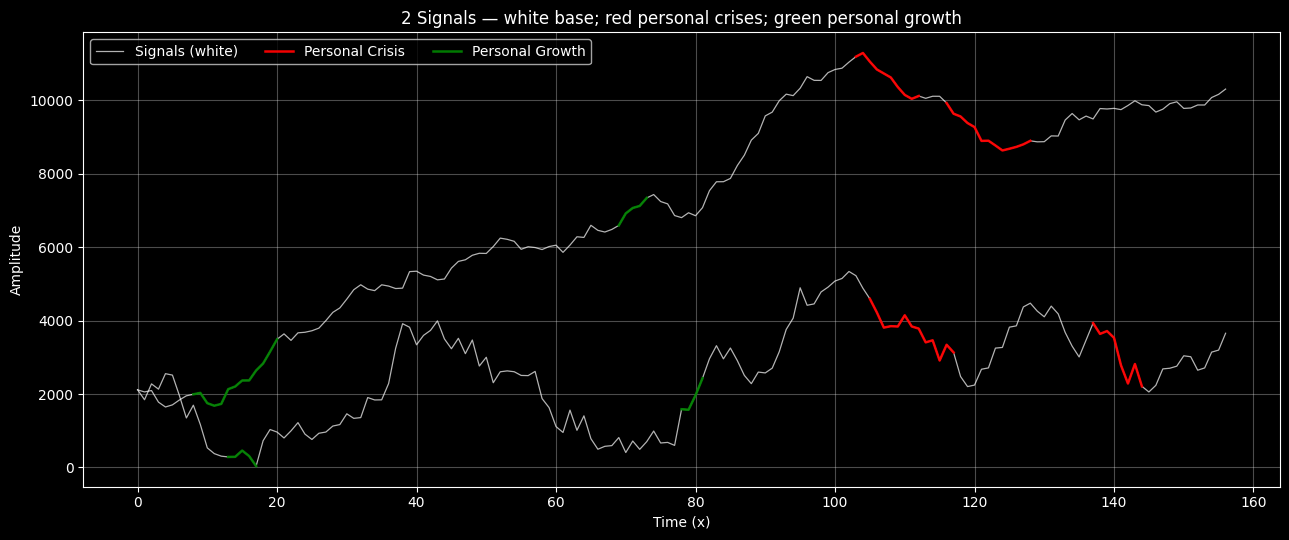

In [181]:
rng = np.random.default_rng(seed=1)

curve_T = 10000
curve_lookback = 16
curve_omega = 0.01
n_curves = 2
curve_cut = 64
l_noise_factor = 5
u_noise_factor = 10

curves, crises_global, growths_global, mask_crisis_personal, mask_growth_personal, _, _ = simulate_curves(
    n=curve_T,
    n_curves=n_curves,
    lookback=curve_lookback,
    rng=rng,
    m_global=3, p_global=2,
    m_personal=2, p_personal=2,
    Lmin=200, Lmax=1000,
    u_limit=100000, d_limit=-50000,
    omega=curve_omega,
    l_noise_factor=l_noise_factor, u_noise_factor=u_noise_factor
)

curves = curves - curves.min() + 1
curves = curves[:,::curve_cut]

print(f"Data Generated. Shape: {curves.shape}")
print(f"Global Crises: {len(crises_global)} intervals | Global Growths: {len(growths_global)} intervals")

plot_signals(
    curves,
    [],
    [],
    mask_crisis_personal[:, ::curve_cut],
    mask_growth_personal[:, ::curve_cut]
)


# Model Training Phase

This section details the key hyperparameters used during the training process. The discount factor $\gamma$ defines the agent's horizon for reward optimization. A value closer to 1 indicates that the model prioritizes long-term gains when evaluating the impact of its current trading decisions.

We have also implemented a feature_look_forward parameter set to 4. This allows the model to observe future price variations, functioning as a look-ahead bias. While this is not possible in real-world trading, it is used here to evaluate whether the architecture can effectively process and exploit trend data before we move to a blind historical data setup.

Other standard deep learning components are included in the implementation but are not described here to maintain focus on the reinforcement learning specificities.

In [163]:
nb_batches = 512
start_samples, end_samples = 64, 64
batch_size, steps = 16, 16
gamma_rl = 0.95
K_epochs = 1
alpha, alpha_factor = 1.0, 0.95
beta, gamma_penalty = 1, 0
entropy_weight = 0
buffer_batch_size = 1024
M, feature_lookback, feature_lookforward = 4, 4, 4
T, n_assets = curve_T // curve_cut, 2
flexibility = 2
n_features = 2 + feature_lookback + feature_lookforward
lr = 0.01
start_gamma_rl, end_gamma_rl = 0.95, 0.95

policy = DenseTradingPolicy(n_assets, flexibility, n_features, 64).to(device)
buy_policy = OnlyBuyPolicy(n_assets, flexibility, n_features, 0).to(device)
optimizer = torch.optim.Adam(policy.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=nb_batches//8, gamma=0.75)
simulation_buffer = MultiQueueBuffer(batch_size * max(start_samples, end_samples) * steps * M)

m_best = 10
top_models = []
p_stop = nb_batches//8
overfit_counter = 0
best_r_test = 0
losses_history = []
rewards_history = []

In [164]:
def optimize_policy(policy, optimizer, buffer, batch_size, alpha, entropy_weight):
    total_loss, count = 0, 0
    for data in buffer.get_batches(batch_size):
        optimizer.zero_grad()
        new_p, logits = policy(data["ip"])
        entropy = Categorical(logits=logits).entropy().mean()
        loss = -compute_grpo_loss(new_p, data["old_probs"], data["a"], data["adv"], 0.1 + 0.1 * alpha)
        current_loss = loss - entropy_weight * entropy
        current_loss.backward()
        optimizer.step()
        total_loss += current_loss.item()
        count += 1
    return total_loss / max(1, count)

def update_model_registry(policy, reward, iteration, top_models, best_reward, overfit_counter, m_best):
    if len(top_models) < m_best:
        heapq.heappush(top_models, (reward, iteration, copy.deepcopy(policy.state_dict())))
    elif reward > top_models[0][0]:
        heapq.heapreplace(top_models, (reward, iteration, copy.deepcopy(policy.state_dict())))

    if reward <= best_reward:
        overfit_counter += 1
    else:
        best_reward = reward
        overfit_counter = 0
    return best_reward, overfit_counter

In [182]:
test_prices, test_features = generate_data(curve_T, n_assets, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor)
test_T = test_prices.shape[0]
test_states, test_inputs, test_indices = generate_states(batch_size, n_assets, test_T, steps, test_prices, test_features, device)
test_samples = 64

In [ ]:
pbar = tqdm(range(nb_batches))

for i in pbar:

    policy.train()
    train_prices, train_features = generate_data(curve_T, n_assets, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor)
    train_T = train_prices.shape[0]
    train_states, train_inputs, train_indices = generate_states(batch_size, n_assets, train_T, steps, train_prices, train_features, device)

    curr_samples = int((1 - i/nb_batches) * start_samples + (i/nb_batches) * end_samples)
    curr_gamma_rl = (1 - i/(nb_batches-1)) * start_gamma_rl + (i/(nb_batches-1)) * end_gamma_rl

    train_ctx = {
        "prices": train_prices, "n_assets": n_assets, "flexibility": flexibility,
        "indices": train_indices, "features": train_features, "beta": beta,
        "sleep_deficit": torch.ones(batch_size, device=device),
        "gamma_penalty": gamma_penalty, "samples": curr_samples, "n_steps": steps
    }

    with torch.no_grad():
        s, ip, a, r, old_p = run_policy(curr_samples, steps, train_ctx, context_modifier, train_states, train_inputs, policy, torch_transition, torch_reward)
        adv = calculate_group_advantage(r, curr_gamma_rl)

    simulation_buffer.append({
        "ip": ip.flatten(0, 2).to(device),
        "a": a.flatten(0, 2).to(device),
        "adv": adv[..., None].expand(*adv.shape, steps).flatten(0, 2).to(device),
        "old_probs": old_p.flatten(0, 2).to(device)
    })

    batch_loss = 0
    for _ in range(K_epochs):
        batch_loss += optimize_policy(policy, optimizer, simulation_buffer, buffer_batch_size, alpha, entropy_weight)

    policy.eval()
    test_ctx = {
        "prices": test_prices, "n_assets": n_assets, "flexibility": flexibility,
        "indices": test_indices, "features": test_features, "beta": beta,
        "sleep_deficit": torch.ones(batch_size, device=device),
        "gamma_penalty": gamma_penalty, "samples": test_samples, "n_steps": steps
    }
    with torch.no_grad():
        _, _, _, r_test, _ = run_policy(test_samples, steps, test_ctx, context_modifier, test_states, test_inputs, policy, torch_transition, torch_reward)

    current_r_test = r_test.mean().item()
    losses_history.append(batch_loss / K_epochs)
    rewards_history.append(current_r_test)

    best_r_test, overfit_counter = update_model_registry(policy, current_r_test, i, top_models, best_r_test, overfit_counter, m_best)

    if overfit_counter >= p_stop:
        print(f"Early stopping at batch {i}: stagnation for {p_stop} steps.")
        break

    alpha *= alpha_factor
    entropy_weight *= alpha_factor
    simulation_buffer.max_size = batch_size * curr_samples * steps * M
    pbar.set_postfix({"R_test": f"{current_r_test:.4f}", "Samples": curr_samples})
    scheduler.step()

# Learning curve visualization

The visualization shows that the training process is stable and performance increases monotonically. The curve eventually reaches a peak where the model stops improving, indicating that it has fully converged and completed its learning phase.

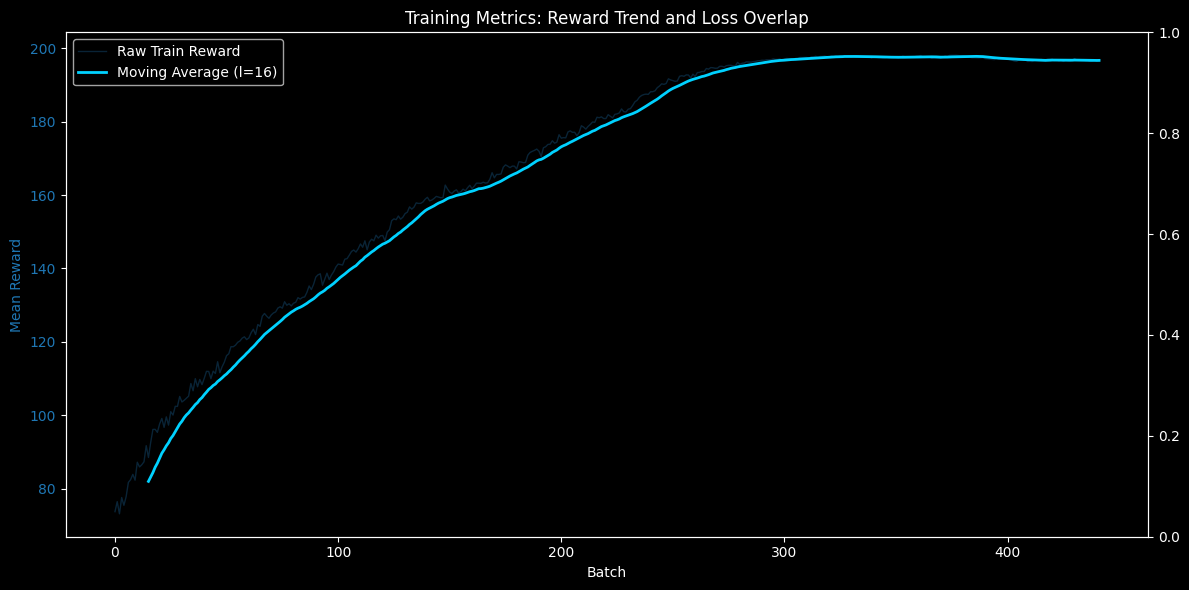

Best Reward Achieved: 198.0737
Final Batch Reward: 196.5587


In [167]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6))

l = 16
rewards_ma = np.convolve(rewards_history, np.ones(l)/l, mode='valid')

ax1.set_xlabel('Batch')
ax1.set_ylabel('Mean Reward', color='tab:blue')
ax1.plot(rewards_history, color='tab:blue', label='Raw Train Reward', alpha=0.3, linewidth=1)
ax1.plot(range(l-1, len(rewards_history)), rewards_ma, color='#00D1FF', label=f'Moving Average (l={l})', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Training Metrics: Reward Trend and Loss Overlap')
fig.tight_layout()
plt.show()

print(f"Best Reward Achieved: {best_r_test:.4f}")
print(f"Final Batch Reward: {rewards_history[-1]:.4f}")

# State Visualization

We performed a Principal Component Analysis projected onto a 2D plane to verify the homogeneity of the state distribution. The visualization shows a uniform distribution, which confirms that the normalization is effective. This explains the model's capacity to generalize across different portfolio configurations and trajectories.

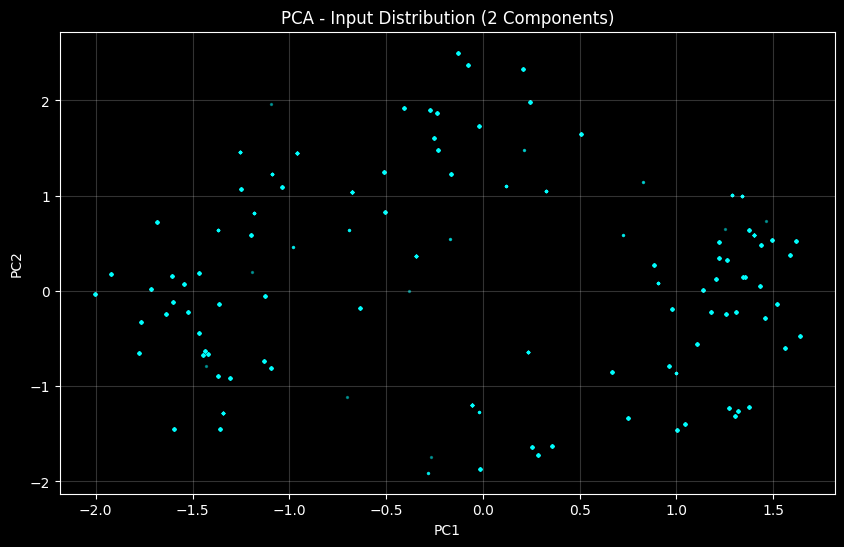

Explained variance ratio: [0.18318489 0.10892774]


In [168]:
inputs_data = simulation_buffer.queues["ip"].cpu().numpy()

pca = PCA(n_components=2)
reduced_data = pca.fit_transform(inputs_data)

plt.style.use('dark_background')
plt.figure(figsize=(10, 6))
plt.scatter(reduced_data[:, 0], reduced_data[:, 1], alpha=0.4, s=2, color='cyan')
plt.title('PCA - Input Distribution (2 Components)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True, alpha=0.2)
plt.show()

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

In [169]:
def plot_policy_comparison(grpo_values, grpo_actions, buy_values, flexibility, title="Portfolio Performance"):
    grpo_v = grpo_values.cpu().detach().numpy().flatten()
    buy_v = buy_values.cpu().detach().numpy().flatten()
    actions_cpu = grpo_actions.cpu().detach().numpy()

    asset_actions = actions_cpu[:, 1]
    buy_idx = np.argwhere(asset_actions < flexibility).flatten()
    sell_idx = np.argwhere(asset_actions > flexibility).flatten()

    plt.style.use('dark_background')
    plt.figure(figsize=(15, 8))
    plt.plot(grpo_v, color='#00D1FF', linewidth=2, label='GRPO Policy')
    plt.plot(buy_v, color='#FF9E00', linewidth=2, linestyle='--', label='Buy & Hold', alpha=0.7)

    if buy_idx.size > 0:
        plt.scatter(buy_idx, grpo_v[buy_idx], color='#00FF00', marker='o', s=20, label='Buy', zorder=5)
    if sell_idx.size > 0:
        plt.scatter(sell_idx, grpo_v[sell_idx], color='#FF0000', marker='o', s=20, label='Sell', zorder=5)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.1)
    plt.show()

# Portfolio performance visualization

This section tracks the portfolio value based on the model's decision process compared to a naive policy of buying and holding assets. The model demonstrates superior performance over the baseline. We must specify that this version incorporates look-ahead bias since the model has access to future market data. The current goal is to validate that the agent is capable of utilizing these future signals to maximize the total return $G_t$ before removing this foresight in subsequent tests.

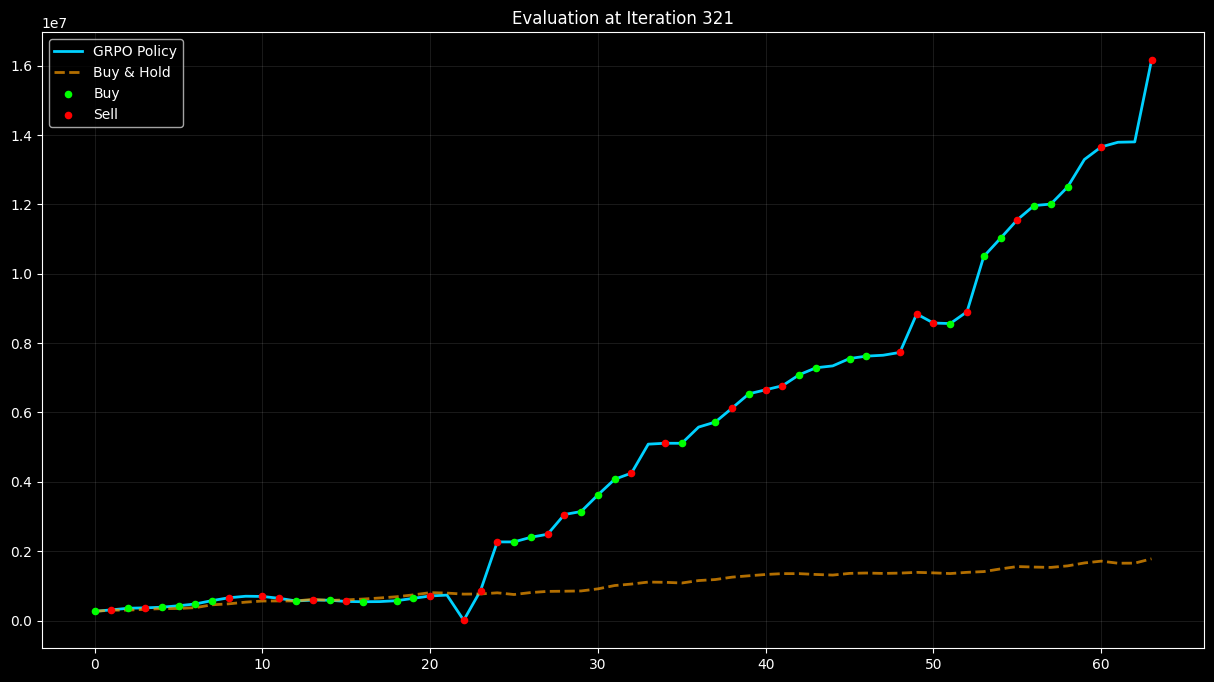

In [170]:
best_reward, iteration, best_weights = top_models[0]
policy.load_state_dict(best_weights)
policy.eval()

eval_prices, eval_features = generate_data(curve_T, n_assets, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor)
eval_steps = 64
eval_states, eval_inputs, eval_idx = generate_states(1, n_assets, eval_prices.shape[0], eval_steps, eval_prices, eval_features, device)

eval_context = {
    "prices": eval_prices, "n_assets": n_assets, "flexibility": flexibility,
    "indices": eval_idx, "features": eval_features, "beta": beta,
    "sleep_deficit": torch.ones(1, device=device), "gamma_penalty": gamma_penalty,
    "samples": 32, "n_steps": eval_steps
}

with torch.no_grad():
    s_grpo, _, a_grpo, _, _ = run_policy(32, eval_steps, eval_context, context_modifier, eval_states, eval_inputs, policy, torch_transition, torch_reward)

    eval_context["samples"] = 1

    s_buy, _, _, _, _ = run_policy(1, eval_steps, eval_context, context_modifier, eval_states, eval_inputs, buy_policy, torch_transition, torch_reward)

plot_policy_comparison(s_grpo[0, :, :, 1, 0].mean(0), a_grpo[0, 0], s_buy[0, 0, :, 1, 0], flexibility, title=f"Evaluation at Iteration {iteration}")

# Phase 2: Training on a blind model

In this section, we remove the look-ahead capability to simulate a realistic trading environment. Here, we use an **LSTM** to enable the model to remember previous states through a memory vector, allowing it to capture temporal dependencies in the historical data.

This phase evaluates whether the model can learn to make effective decisions using only current and past data. We are monitoring the agent's ability to adapt its policy without access to future market information.

In [186]:
nb_batches = 512
start_samples, end_samples = 64, 64
batch_size, steps = 16, 16
gamma_rl = 0.95
K_epochs = 1
alpha, alpha_factor = 1.0, 0.95
beta, gamma_penalty = 1, 0
entropy_weight = 0
buffer_batch_size = 1024
M, feature_lookback, feature_lookforward = 4, 1, 0
T, n_assets = curve_T // curve_cut, 2
flexibility = 2
n_features = 2 + feature_lookback + feature_lookforward
lr = 0.01
start_gamma_rl, end_gamma_rl = 0.95, 0.95

blind_policy = LSTMTradingPolicy(n_assets, flexibility, n_features, 32, num_layers=2).to(device)

optimizer = torch.optim.Adam(blind_policy.parameters(), lr=lr)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=nb_batches//8, gamma=0.75)
simulation_buffer = MultiQueueBuffer(batch_size * max(start_samples, end_samples) * steps * M)

m_best = 10
top_models = []
p_stop = nb_batches//4
overfit_counter = 0
best_r_test = 0
losses_history = []
rewards_history = []

In [183]:
test_prices, test_features = generate_data(curve_T, n_assets, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor, (0,2))
test_T = test_prices.shape[0]
test_states, test_inputs, test_indices = generate_states(batch_size, n_assets, test_T, steps, test_prices, test_features, device)
test_samples = 64

In [ ]:
pbar = tqdm(range(nb_batches))

for i in pbar:

    blind_policy.train()
    train_prices, train_features = generate_data(curve_T, n_assets, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor, 0)
    train_T = train_prices.shape[0]
    train_states, train_inputs, train_indices = generate_states(batch_size, n_assets, train_T, steps, train_prices, train_features, device)

    curr_samples = int((1 - i/nb_batches) * start_samples + (i/nb_batches) * end_samples)
    curr_gamma_rl = (1 - i/(nb_batches-1)) * start_gamma_rl + (i/(nb_batches-1)) * end_gamma_rl

    train_ctx = {
        "prices": train_prices, "n_assets": n_assets, "flexibility": flexibility,
        "indices": train_indices, "features": train_features, "beta": beta,
        "sleep_deficit": torch.ones(batch_size, device=device),
        "gamma_penalty": gamma_penalty, "samples": curr_samples, "n_steps": steps
    }

    with torch.no_grad():
        s, ip, a, r, old_p = run_policy(curr_samples, steps, train_ctx, context_modifier, train_states, train_inputs, blind_policy, torch_transition, torch_reward)
        adv = calculate_group_advantage(r, curr_gamma_rl)

    simulation_buffer.append({
        "ip": ip.flatten(0, 2).to(device),
        "a": a.flatten(0, 2).to(device),
        "adv": adv[..., None].expand(*adv.shape, steps).flatten(0, 2).to(device),
        "old_probs": old_p.flatten(0, 2).to(device)
    })

    batch_loss = 0
    for _ in range(K_epochs):
        batch_loss += optimize_policy(blind_policy, optimizer, simulation_buffer, buffer_batch_size, alpha, entropy_weight)

    blind_policy.eval()
    test_ctx = {
        "prices": test_prices, "n_assets": n_assets, "flexibility": flexibility,
        "indices": test_indices, "features": test_features, "beta": beta,
        "sleep_deficit": torch.ones(batch_size, device=device),
        "gamma_penalty": gamma_penalty, "samples": test_samples, "n_steps": steps
    }
    with torch.no_grad():
        _, _, _, r_test, _ = run_policy(test_samples, steps, test_ctx, context_modifier, test_states, test_inputs, blind_policy, torch_transition, torch_reward)

    current_r_test = r_test.mean().item()
    losses_history.append(batch_loss / K_epochs)
    rewards_history.append(current_r_test)

    best_r_test, overfit_counter = update_model_registry(blind_policy, current_r_test, i, top_models, best_r_test, overfit_counter, m_best)

    if overfit_counter >= p_stop:
        print(f"Early stopping at batch {i}: stagnation for {p_stop} steps.")
        break

    alpha *= alpha_factor
    entropy_weight *= alpha_factor
    simulation_buffer.max_size = batch_size * curr_samples * steps * M
    pbar.set_postfix({"R_test": f"{current_r_test:.4f}", "Samples": curr_samples})
    scheduler.step()

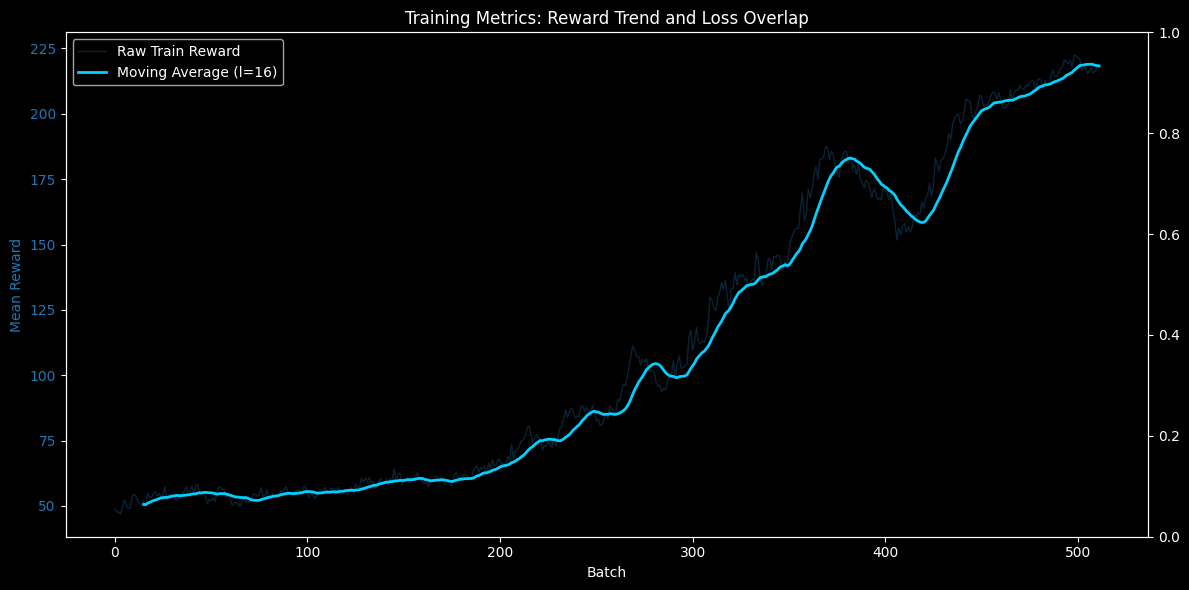

Best Reward Achieved: 222.3885
Final Batch Reward: 217.9317


In [188]:
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(12, 6))

l = 16
rewards_ma = np.convolve(rewards_history, np.ones(l)/l, mode='valid')

ax1.set_xlabel('Batch')
ax1.set_ylabel('Mean Reward', color='tab:blue')
ax1.plot(rewards_history, color='tab:blue', label='Raw Train Reward', alpha=0.3, linewidth=1)
ax1.plot(range(l-1, len(rewards_history)), rewards_ma, color='#00D1FF', label=f'Moving Average (l={l})', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Training Metrics: Reward Trend and Loss Overlap')
fig.tight_layout()
plt.show()

print(f"Best Reward Achieved: {best_r_test:.4f}")
print(f"Final Batch Reward: {rewards_history[-1]:.4f}")

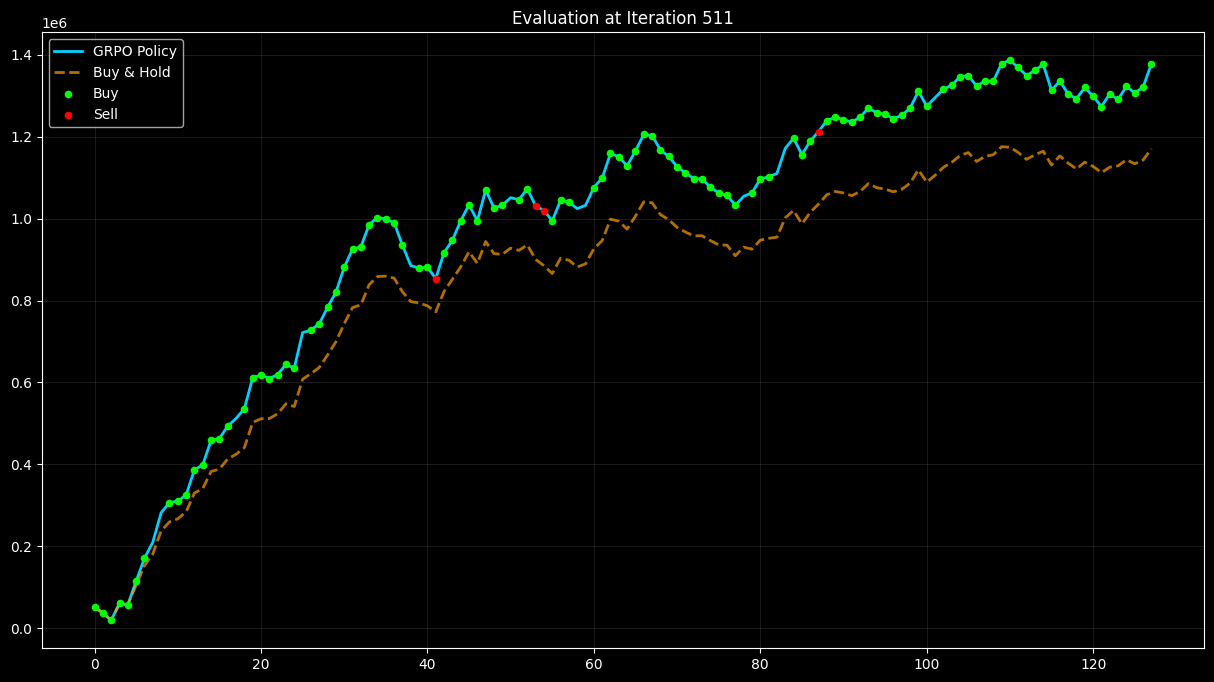

In [219]:
best_reward, iteration, best_weights = top_models[0]
blind_policy.load_state_dict(best_weights)
blind_policy.eval()

eval_prices, eval_features = generate_data(curve_T, n_assets, curve_lookback, curve_omega, curve_cut, feature_lookback, feature_lookforward, l_noise_factor, u_noise_factor)
eval_steps = 128
eval_samples = 64
eval_states, eval_inputs, eval_idx = generate_states(1, n_assets, eval_prices.shape[0], eval_steps, eval_prices, eval_features, device)

eval_context = {
    "prices": eval_prices, "n_assets": n_assets, "flexibility": flexibility,
    "indices": eval_idx, "features": eval_features, "beta": beta,
    "sleep_deficit": torch.ones(1, device=device), "gamma_penalty": gamma_penalty,
    "samples": eval_samples, "n_steps": eval_steps
}

with torch.no_grad():
    s_grpo, _, a_grpo, _, _ = run_policy(eval_samples, eval_steps, eval_context, context_modifier, eval_states, eval_inputs, blind_policy, torch_transition, torch_reward)

    eval_context["samples"] = 1

    s_buy, _, _, _, _ = run_policy(1, eval_steps, eval_context, context_modifier, eval_states, eval_inputs, buy_policy, torch_transition, torch_reward)

plot_policy_comparison(s_grpo[0, :, :, 1, 0].mean(0), a_grpo[0, 0], s_buy[0, 0, :, 1, 0], flexibility, title=f"Evaluation at Iteration {iteration}")

# Results

The training curve indicates that the model is learning, and the portfolio evolution shows that it seems to perform better than a simple buy and hold strategy for this test. This result suggests that the model is starting to capture meaningful patterns in the data, despite the high noise levels and weak linear dependencies.
The next step of this project will involve implementing low-accuracy asset predictions to provide the model with a minimal signal and observe if it can further improve its decision-making process.
